In [1]:
# Import thư viện 
import pandas as pd 
import numpy as np
from glob import glob
from PIL import Image

# Assignment 1

## Load data: train, val, set
- với normal ta gán nhãn là -1
- với pnewmonia ta gán nhãn là 1 

In [2]:
#Hàm load data
def loadData(pathData, image_size=(128, 128)):
    X, y = [], []
    # NORMAL gán nhãn là -1 
    for path in glob(f"{pathData}/NORMAL/*.jpeg"):
        img = Image.open(path).convert("L")
        img = img.resize(image_size)
        arr = np.array(img, dtype=np.float32) / 255.0
        X.append(arr.flatten())
        y.append(-1)

    # PNEUMONIA gán nhãn là 1 
    for path in glob(f"{pathData}/PNEUMONIA/*.jpeg"):
        img = Image.open(path).convert("L")
        img = img.resize(image_size)
        arr = np.array(img, dtype=np.float32) / 255.0
        X.append(arr.flatten())
        y.append(1)
    return np.array(X), np.array(y)

## Bắt đầu load dữ liệu 

In [120]:
path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
X_train, y_train = loadData(path + "/train")
X_val, y_val     = loadData(path + "/val")
X_test, y_test   = loadData(path + "/test")
print("Train:",X_train.shape)
print("Val  :",X_val.shape)
print("Test :",X_test.shape)

Train: (5216, 16384)
Val  : (16, 16384)
Test : (624, 16384)


## Chuẩn hóa dữ liệu 

In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Mô hình soft-margin SVM với kernel = linear
- Lớp SoftMarginSVM cài đặt một mô hình SVM tuyến tính với soft-margin, trong đó siêu phẳng phân tách được học thông qua tối ưu hàm mất mát hinge kết hợp với regularization L2. Toàn bộ quá trình huấn luyện được thực hiện bằng phương pháp tối ưu lặp kiểu SGD theo tinh thần của Pegasos, thay vì giải bài toán quy hoạch bậc hai như SVM cổ điển.

- Hàm khởi tạo __init__ dùng để thiết lập các siêu tham số của mô hình. Tham số C điều khiển mức độ đánh đổi giữa việc tối đa hóa biên và việc cho phép sai số phân loại. Số epoch quy định số lần lặp qua toàn bộ dữ liệu huấn luyện. Tùy chọn shuffle cho phép trộn dữ liệu mỗi epoch để tránh bias trong quá trình cập nhật. Ngoài ra, mô hình hỗ trợ cân bằng lớp thông qua class_weight, điều chỉnh ngưỡng dự đoán thông qua threshold, và cho phép in thông tin huấn luyện qua verbose. Các biến trạng thái như vector trọng số w, bias b và lịch sử loss cũng được khởi tạo tại đây.

- Hàm _prepare_y có nhiệm vụ chuẩn hóa nhãn đầu vào về dạng chuẩn của SVM là {-1, 1}. Nếu dữ liệu đầu vào sử dụng nhãn {0, 1}, hàm sẽ chuyển đổi về {-1, 1}. Nếu nhãn không thuộc hai dạng hợp lệ này, hàm sẽ báo lỗi để tránh sai lệch trong tính toán margin.

- Hàm _get_sample_weights xử lý việc gán trọng số cho từng mẫu dữ liệu nhằm hỗ trợ bài toán mất cân bằng lớp. Khi không sử dụng trọng số, tất cả các mẫu được gán giá trị bằng nhau. Khi chọn chế độ "balanced", trọng số của mỗi lớp được tính ngược với tần suất xuất hiện của lớp đó, giúp giảm bias về phía lớp chiếm đa số. Nếu người dùng cung cấp một dictionary, trọng số sẽ được gán theo cấu hình tùy chỉnh.

- Hàm decision_function tính giá trị đầu ra thô của mô hình, tức là tích vô hướng giữa vector đặc trưng và trọng số cộng với bias. Đây chính là giá trị dùng để xác định khoảng cách có dấu của điểm dữ liệu đến siêu phẳng phân tách.

- Hàm predict sử dụng giá trị từ decision_function để đưa ra dự đoán nhãn. Một ngưỡng được sử dụng để quyết định phân loại, mặc định là 0. Nếu giá trị lớn hơn hoặc bằng ngưỡng thì dự đoán là lớp dương, ngược lại là lớp âm. Việc cho phép thay đổi ngưỡng giúp điều chỉnh trade-off giữa precision và recall.

- Hàm compute_loss tính toán giá trị hàm mất mát của mô hình. Hàm này bao gồm hai thành phần chính là regularization L2 trên vector trọng số và hinge loss trên dữ liệu. Hinge loss đo mức độ vi phạm điều kiện margin của từng mẫu, và chỉ những mẫu có margin nhỏ hơn 1 mới đóng góp vào loss. Tổng loss được tính trung bình có trọng số nếu sử dụng class_weight.

- Hàm _metrics_from_preds thực hiện tính toán các chỉ số đánh giá bao gồm precision, recall và F1-score dựa trên nhãn thật và nhãn dự đoán. Các giá trị TP, FP và FN được xác định từ đó, và các công thức chuẩn được áp dụng với một lượng nhỏ epsilon để tránh chia cho 0.

- Hàm fit là phần quan trọng nhất, thực hiện quá trình huấn luyện mô hình. Thuật toán sử dụng cập nhật từng mẫu với learning rate giảm dần theo số bước lặp. Tại mỗi bước, mô hình kiểm tra điều kiện margin. Nếu mẫu vi phạm margin, cả trọng số và bias sẽ được cập nhật theo hướng giảm loss, đồng thời có thêm thành phần regularization. Nếu không vi phạm, chỉ áp dụng bước shrinkage để giảm độ lớn của trọng số. Sau mỗi epoch, mô hình tính loss trên toàn bộ tập huấn luyện để theo dõi quá trình hội tụ. Nếu có tập validation, mô hình sẽ theo dõi F1-score và lưu lại bộ tham số tốt nhất. Ngoài ra, một bước projection được áp dụng để đảm bảo norm của vector trọng số không vượt quá giới hạn lý thuyết, giúp ổn định quá trình học.

- Hàm score đánh giá nhanh mô hình trên một tập dữ liệu bằng cách trả về các chỉ số precision, recall, F1-score và accuracy. 

In [122]:
import numpy as np
import matplotlib.pyplot as plt


class SoftMarginSVM:
    def __init__(
        self,
        C=1.0,
        epochs=50,
        shuffle=True,
        random_state=42,
        class_weight=None,
        threshold=0.0,
        verbose=True,
    ):
        self.C = float(C)
        self.epochs = int(epochs)
        self.shuffle = shuffle
        self.class_weight = class_weight
        self.threshold = float(threshold)
        self.verbose = verbose
        self.rng = np.random.default_rng(random_state)

        self.w = None
        self.b = 0.0
        self.loss_history = []

    def _prepare_y(self, y):
        y = np.asarray(y, dtype=np.float32).ravel()
        uniq = set(np.unique(y).tolist())

        if uniq <= {0.0, 1.0}:
            y = np.where(y == 1.0, 1.0, -1.0).astype(np.float32)
        elif not uniq.issubset({-1.0, 1.0}):
            raise ValueError("y must be in {0,1} or {-1,1}")
        return y

    def _get_sample_weights(self, y):
        y = self._prepare_y(y)

        if self.class_weight is None:
            return np.ones_like(y, dtype=np.float32)

        if self.class_weight == "balanced":
            n_pos = np.sum(y == 1)
            n_neg = np.sum(y == -1)

            w_pos = len(y) / (2.0 * max(n_pos, 1))
            w_neg = len(y) / (2.0 * max(n_neg, 1))

            return np.where(y == 1, w_pos, w_neg).astype(np.float32)

        if isinstance(self.class_weight, dict):
            w_pos = float(self.class_weight.get(1, 1.0))
            w_neg = float(self.class_weight.get(-1, 1.0))
            return np.where(y == 1, w_pos, w_neg).astype(np.float32)

        return np.ones_like(y, dtype=np.float32)

    def decision_function(self, X):
        if self.w is None:
            raise ValueError("Model is not fitted yet.")
        X = np.asarray(X, dtype=np.float32)
        return X @ self.w + self.b

    def predict(self, X, threshold=None):
        if threshold is None:
            threshold = self.threshold
        scores = self.decision_function(X)
        return np.where(scores >= threshold, 1, -1).astype(np.int32)

    def compute_loss(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        y = self._prepare_y(y)
        sw = self._get_sample_weights(y)

        scores = self.decision_function(X)
        margins = 1.0 - y * scores
        hinge = np.maximum(0.0, margins)

        hinge_loss = np.sum(sw * hinge) / (np.sum(sw) + 1e-12)
        reg_loss = 0.5 * np.dot(self.w, self.w)

        return float(reg_loss + self.C * hinge_loss)

    def _metrics_from_preds(self, y_true, y_pred):
        y_true = self._prepare_y(y_true).astype(np.int32)
        y_pred = np.asarray(y_pred, dtype=np.int32).ravel()

        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == -1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == -1))

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2.0 * precision * recall / (precision + recall + 1e-12)

        return precision, recall, f1

    def report(self, X, y):
        y_pred = self.predict(X)
        precision, recall, f1 = self._metrics_from_preds(y, y_pred)

        print(f"precision={precision:.4f}")
        print(f"recall={recall:.4f}")
        print(f"f1={f1:.4f}")

        return {
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
        }

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X, dtype=np.float32)
        y = self._prepare_y(y)
        sw = self._get_sample_weights(y)

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=np.float32)
        self.b = 0.0

        self.loss_history = []

        best_f1 = -1.0
        best_w = self.w.copy()
        best_b = self.b

        lambda_ = 1.0 / max(self.C, 1e-12)
        t = 0

        for epoch in range(1, self.epochs + 1):
            indices = np.arange(n_samples)
            if self.shuffle:
                self.rng.shuffle(indices)

            for i in indices:
                t += 1
                eta = 1.0 / (lambda_ * t)

                xi = X[i]
                yi = y[i]
                wi = sw[i]

                score = float(np.dot(self.w, xi) + self.b)
                margin = yi * score

                if margin < 1.0:
                    self.w = (1.0 - eta * lambda_) * self.w + eta * wi * yi * xi
                    self.b = self.b + eta * wi * yi
                else:
                    self.w = (1.0 - eta * lambda_) * self.w

                norm_w = np.linalg.norm(self.w)
                limit = 1.0 / np.sqrt(lambda_)
                if norm_w > limit:
                    self.w = self.w * (limit / (norm_w + 1e-12))

            train_loss = self.compute_loss(X, y)
            self.loss_history.append(train_loss)

            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                _, _, val_f1 = self._metrics_from_preds(y_val, y_val_pred)
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_w = self.w.copy()
                    best_b = float(self.b)

            if self.verbose:
                print(f"epoch={epoch:03d} | train_loss={train_loss:.4f}")

        if X_val is not None and y_val is not None and best_f1 >= 0:
            self.w = best_w
            self.b = best_b

        return self

    def score(self, X, y):
        y_pred = self.predict(X)
        precision, recall, f1 = self._metrics_from_preds(y, y_pred)
        acc = np.mean(self._prepare_y(y).astype(np.int32) == y_pred)

        return {
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "acc": float(acc),
        }

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.loss_history, label="Train Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Soft-Margin SVM Loss Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

## Huấn luyện mô hình
- Với các tham số: C = 10, epochs = 100
  

In [123]:
model = SoftMarginSVM(
    C=10,
    epochs=100,
    class_weight="balanced",
    random_state=42,
    verbose=True
)

model.fit(X_train, y_train, X_val, y_val)


epoch=001 | train_loss=13.1661
epoch=002 | train_loss=6.0892
epoch=003 | train_loss=4.2557
epoch=004 | train_loss=2.5624
epoch=005 | train_loss=2.6421
epoch=006 | train_loss=2.3463
epoch=007 | train_loss=1.9839
epoch=008 | train_loss=1.8939
epoch=009 | train_loss=1.8565
epoch=010 | train_loss=1.7452
epoch=011 | train_loss=1.5197
epoch=012 | train_loss=1.7130
epoch=013 | train_loss=1.5596
epoch=014 | train_loss=1.5116
epoch=015 | train_loss=1.4066
epoch=016 | train_loss=1.5200
epoch=017 | train_loss=1.2641
epoch=018 | train_loss=1.2811
epoch=019 | train_loss=1.2404
epoch=020 | train_loss=1.2654
epoch=021 | train_loss=1.3282
epoch=022 | train_loss=1.1919
epoch=023 | train_loss=1.2076
epoch=024 | train_loss=1.1526
epoch=025 | train_loss=1.4423
epoch=026 | train_loss=1.1348
epoch=027 | train_loss=1.1715
epoch=028 | train_loss=1.1021
epoch=029 | train_loss=1.1830
epoch=030 | train_loss=1.1250
epoch=031 | train_loss=1.1319
epoch=032 | train_loss=1.0889
epoch=033 | train_loss=1.0863
epoch=034

## Biểu đồ loss

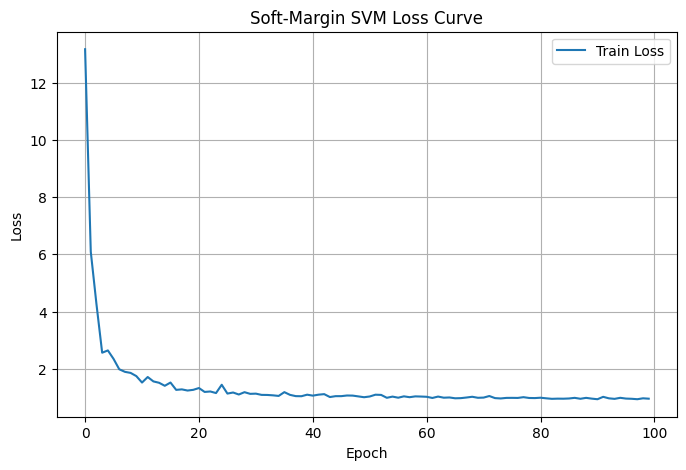

In [129]:
model.plot_loss()

## Kết quả 

In [131]:
scores = model.score(X_test, y_test)
print("Precision của SoftSVM là:", scores["precision"])
print("Recall:", scores["recall"])
print("F1:", scores["f1"])
print("Accuracy:", scores["acc"])

Precision của SoftSVM là: 0.7530612244897944
Recall: 0.9461538461538437
F1: 0.838636363635868
Accuracy: 0.7724358974358975


# Assignment 2 

In [133]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

## Huấn luyện với tham số C = 10

In [134]:
clf = SVC(
    kernel='linear', 
    C=10,                 
    class_weight='balanced'
)

clf.fit(X_train, y_train)

SVC(C=10, class_weight='balanced', kernel='linear')

In [135]:
y_pred_sklearn = clf.predict(X_test)

In [138]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

p = precision_score(y_test, y_pred_sklearn)
r = recall_score(y_test, y_pred_sklearn)
f = f1_score(y_test, y_pred_sklearn)
a = accuracy_score(y_test, y_pred_sklearn)
print("Điểm của sklearn SVM là:")
print("Precision:", p)
print("Recall:", r)
print("F1:", f)
print("Accuracy:", a)

Điểm của sklearn SVM là:
Precision: 0.7206703910614525
Recall: 0.9923076923076923
F1: 0.8349514563106796
Accuracy: 0.7548076923076923


# Nhận xét, so sánh 
- Hai mô hình (SoftMarginSVM tự cài đặt và SVM của sklearn) cho kết quả F1 gần tương đương (~0.83–0.84), cho thấy hiệu năng tổng thể là tương đương nhau.
SoftMarginSVM có precision cao hơn (0.753 > 0.721) → dự đoán dương “chắc chắn” hơn, ít false positive hơn.
- SoftMarginSVM có recall thấp hơn (0.946 < 0.992) → bỏ sót nhiều mẫu dương hơn so với sklearn.
Ngược lại, sklearn SVM có recall rất cao (~0.99) → gần như bắt hết mẫu dương, nhưng đánh đổi bằng precision thấp hơn (nhiều false positive hơn).
- Accuracy của SoftMarginSVM cao hơn (0.772 > 0.755) → tổng thể phân loại đúng nhiều hơn một chút.

=> Sự khác biệt chủ yếu đến từ:
- Cách tối ưu: SoftMarginSVM dùng SGD (Pegasos), sklearn dùng solver tối ưu chính xác hơn.
- Phân bố score khác nhau → cùng threshold nhưng hành vi phân loại khác.